bert_02_cls_classification.py
==============================
Stage 2 of the BERT walkthrough — sentence classification via [CLS] token.

Pipeline:
    x  (T, d_model)                      loaded from bert_01
      → W_Q, W_K, W_V projections
      → split into H heads
      → F.scaled_dot_product_attention   (bidirectional, no mask)
      → concat heads → W_O
      → output[0]                        ← [CLS] token only
      → Linear(d_model, n_classes)       ← classifier head
      → cross-entropy(label=1)           ← positive sentiment
      → loss.backward()
      → gradient summary + figures

Key idea
--------
[CLS] has no lexical meaning. During training it is forced to summarise
the entire sequence because the classification loss only reads position 0.
It learns to do this through attention — by attending to all other tokens
and aggregating their information into a single vector.

After backward() you can see that x.grad is non-zero at EVERY position,
not just [CLS] — because [CLS] attended to all of them, their keys and
values influenced the [CLS] output, so the loss signal flows back through
every token.

In [3]:
cd "/content/drive/MyDrive/Courses/AI/masked_attention/bert"

/content/drive/MyDrive/Courses/AI/masked_attention/bert


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [4]:
# ── 0. Load ───────────────────────────────────────────────────────────────────

data        = torch.load("bert_embeddings.pt", weights_only=True)
x_base      = data["x"]           # (T, d_model)
tokens      = data["tokens"]       # list[str] with [CLS]/[SEP]
T           = data["T"]
D_MODEL     = data["D_MODEL"]
VOCAB_SIZE  = data["VOCAB_SIZE"]
SENTENCE    = data["SENTENCE"]

LABEL       = torch.tensor([1])    # positive sentiment

print("=" * 60)
print("Loaded from bert_embeddings.pt")
print("=" * 60)
print(f"  Sentence : '{SENTENCE}'")
print(f"  Tokens   : {tokens}")
print(f"  Label    : {LABEL.item()}  (positive sentiment)")

Loaded from bert_embeddings.pt
  Sentence : 'the cat sat on the mat'
  Tokens   : ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']
  Label    : 1  (positive sentiment)


In [5]:
# ── 1. Hyperparameters + projections ─────────────────────────────────────────

N_HEADS  = 4
D_HEAD   = D_MODEL // N_HEADS
N_CLASSES = 2      # negative / positive

torch.manual_seed(42)

W_Q = nn.Linear(D_MODEL, D_MODEL, bias=False)
W_K = nn.Linear(D_MODEL, D_MODEL, bias=False)
W_V = nn.Linear(D_MODEL, D_MODEL, bias=False)
W_O = nn.Linear(D_MODEL, D_MODEL, bias=False)

classifier = nn.Linear(D_MODEL, N_CLASSES)   # reads only [CLS] output

x = x_base.clone().requires_grad_(True)
x.retain_grad()

print(f"\n  N_HEADS={N_HEADS}  D_HEAD={D_HEAD}  N_CLASSES={N_CLASSES}")


  N_HEADS=4  D_HEAD=16  N_CLASSES=2


In [6]:
# ── 2. Q, K, V ───────────────────────────────────────────────────────────────

Q = W_Q(x)
K = W_K(x)
V = W_V(x)

print("\n" + "=" * 60)
print("STEP 1 — Q, K, V PROJECTIONS")
print("=" * 60)
print(f"  Q : {Q.shape}")
print(f"  K : {K.shape}")
print(f"  V : {V.shape}")


STEP 1 — Q, K, V PROJECTIONS
  Q : torch.Size([8, 64])
  K : torch.Size([8, 64])
  V : torch.Size([8, 64])


In [7]:
# ── 3. Split heads ────────────────────────────────────────────────────────────

def split_heads(z: torch.Tensor) -> torch.Tensor:
    """(T, d_model) → (N_HEADS, T, D_HEAD)"""
    T_, d = z.shape
    return z.view(T_, N_HEADS, D_HEAD).permute(1, 0, 2)

Q_h = split_heads(Q)
K_h = split_heads(K)
V_h = split_heads(V)

print("\n" + "=" * 60)
print("STEP 2 — SPLIT INTO HEADS")
print("=" * 60)
print(f"  Q_h : {Q_h.shape}  (N_HEADS, T, D_HEAD)")


STEP 2 — SPLIT INTO HEADS
  Q_h : torch.Size([4, 8, 16])  (N_HEADS, T, D_HEAD)


In [8]:
# ── 4. Bidirectional attention ────────────────────────────────────────────────
#
# No causal mask. [CLS] at position 0 attends to every token in the sequence.
# That is exactly what makes it a useful summary vector — it can gather
# information from anywhere.

attn_out = F.scaled_dot_product_attention(
    Q_h, K_h, V_h,
    attn_mask=None,
    dropout_p=0.0,
    scale=D_HEAD ** -0.5,
)
# attn_out : (N_HEADS, T, D_HEAD)

# Recompute weights for visualisation
with torch.no_grad():
    scores = (Q_h @ K_h.transpose(-2, -1)) * (D_HEAD ** -0.5)
    attn_w = scores.softmax(dim=-1)    # (N_HEADS, T, T)

print("\n" + "=" * 60)
print("STEP 3 — BIDIRECTIONAL ATTENTION")
print("=" * 60)
print(f"  attn_out : {attn_out.shape}")
print(f"\n  [CLS] attention weights (head 0) — what [CLS] attends to:")
print(f"  {'token':>8}  {'weight':>8}")
for j, tok in enumerate(tokens):
    print(f"  {tok:>8}  {attn_w[0, 0, j].item():8.4f}")   # row 0 = [CLS] query


STEP 3 — BIDIRECTIONAL ATTENTION
  attn_out : torch.Size([4, 8, 16])

  [CLS] attention weights (head 0) — what [CLS] attends to:
     token    weight
     [CLS]    0.1098
       the    0.0662
       cat    0.0906
       sat    0.1165
        on    0.1438
       the    0.2300
       mat    0.1480
     [SEP]    0.0951


In [9]:
# ── 5. Concat + W_O ──────────────────────────────────────────────────────────

def concat_heads(z: torch.Tensor) -> torch.Tensor:
    """(N_HEADS, T, D_HEAD) → (T, d_model)"""
    H, T_, d_h = z.shape
    return z.permute(1, 0, 2).contiguous().view(T_, H * d_h)

attn_proj = W_O(concat_heads(attn_out))   # (T, d_model)

print("\n" + "=" * 60)
print("STEP 4 — CONCAT HEADS + W_O")
print("=" * 60)
print(f"  attn_proj : {attn_proj.shape}")


STEP 4 — CONCAT HEADS + W_O
  attn_proj : torch.Size([8, 64])


In [10]:
# ── 6. CLS classification ─────────────────────────────────────────────────────
#
# Take ONLY position 0 — the [CLS] token.
# Everything else is discarded for the classification decision.
# The classifier is a single linear layer: (d_model,) → (n_classes,)

cls_vector = attn_proj[0]                  # (d_model,)  ← position 0 only
logits     = classifier(cls_vector)        # (n_classes,)
probs      = logits.softmax(dim=-1)        # (n_classes,)

print("\n" + "=" * 60)
print("STEP 5 — CLS CLASSIFICATION")
print("=" * 60)
print(f"  attn_proj[0]  (= cls_vector) : {cls_vector.shape}  ← position 0 only")
print(f"  classifier(cls_vector)       : {logits.shape}  raw logits")
print(f"  logits  : {logits.detach().numpy().round(4)}")
print(f"  probs   : {probs.detach().numpy().round(4)}  [neg, pos]")
print(f"  pred    : {'positive' if probs.argmax() == 1 else 'negative'}  "
      f"(untrained — random weights)")


STEP 5 — CLS CLASSIFICATION
  attn_proj[0]  (= cls_vector) : torch.Size([64])  ← position 0 only
  classifier(cls_vector)       : torch.Size([2])  raw logits
  logits  : [0.3075 0.0982]
  probs   : [0.5521 0.4479]  [neg, pos]
  pred    : negative  (untrained — random weights)


In [11]:
# ── 7. Loss + backward ───────────────────────────────────────────────────────

loss = F.cross_entropy(logits.unsqueeze(0), LABEL)   # unsqueeze: (2,)→(1,2)

print("\n" + "=" * 60)
print("STEP 6 — LOSS + BACKWARD")
print("=" * 60)
print(f"  label : {LABEL.item()}  (positive)")
print(f"  loss  : {loss.item():.6f}")

loss.backward()


STEP 6 — LOSS + BACKWARD
  label : 1  (positive)
  loss  : 0.803273


In [12]:
# ── 8. Gradient summary ───────────────────────────────────────────────────────

params = {
    "W_Q.weight":          W_Q.weight,
    "W_K.weight":          W_K.weight,
    "W_V.weight":          W_V.weight,
    "W_O.weight":          W_O.weight,
    "classifier.weight":   classifier.weight,
}

print(f"\n  {'Parameter':<22}  {'shape':<22}  {'L2 norm':>12}  {'max |grad|':>12}")
print("  " + "-" * 72)
for name, p in params.items():
    g = p.grad
    print(f"  {name:<22}  {str(g.shape):<22}  {g.norm().item():>12.6f}"
          f"  {g.abs().max().item():>12.6f}")

print(f"\n  x.grad per token — loss flows back through every token")
print(f"  because [CLS] attended to all of them:")
print(f"\n  {'token':>8}  {'||x.grad||':>12}")
for i, tok in enumerate(tokens):
    flag = "  ← [CLS] summary vector" if i == 0 else ""
    print(f"  {tok:>8}  {x.grad[i].norm().item():>12.6f}{flag}")


  Parameter               shape                        L2 norm    max |grad|
  ------------------------------------------------------------------------
  W_Q.weight              torch.Size([64, 64])        1.033018      0.158893
  W_K.weight              torch.Size([64, 64])        0.705029      0.081286
  W_V.weight              torch.Size([64, 64])        2.010712      0.202767
  W_O.weight              torch.Size([64, 64])        2.508256      0.211217
  classifier.weight       torch.Size([2, 64])         2.295949      0.578327

  x.grad per token — loss flows back through every token
  because [CLS] attended to all of them:

     token    ||x.grad||
     [CLS]      0.053064  ← [CLS] summary vector
       the      0.023979
       cat      0.018532
       sat      0.019467
        on      0.037325
       the      0.019684
       mat      0.018433
     [SEP]      0.018200


/tmp/ipykernel_271/1790720873.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(names, rotation=20, ha="right", fontsize=8)


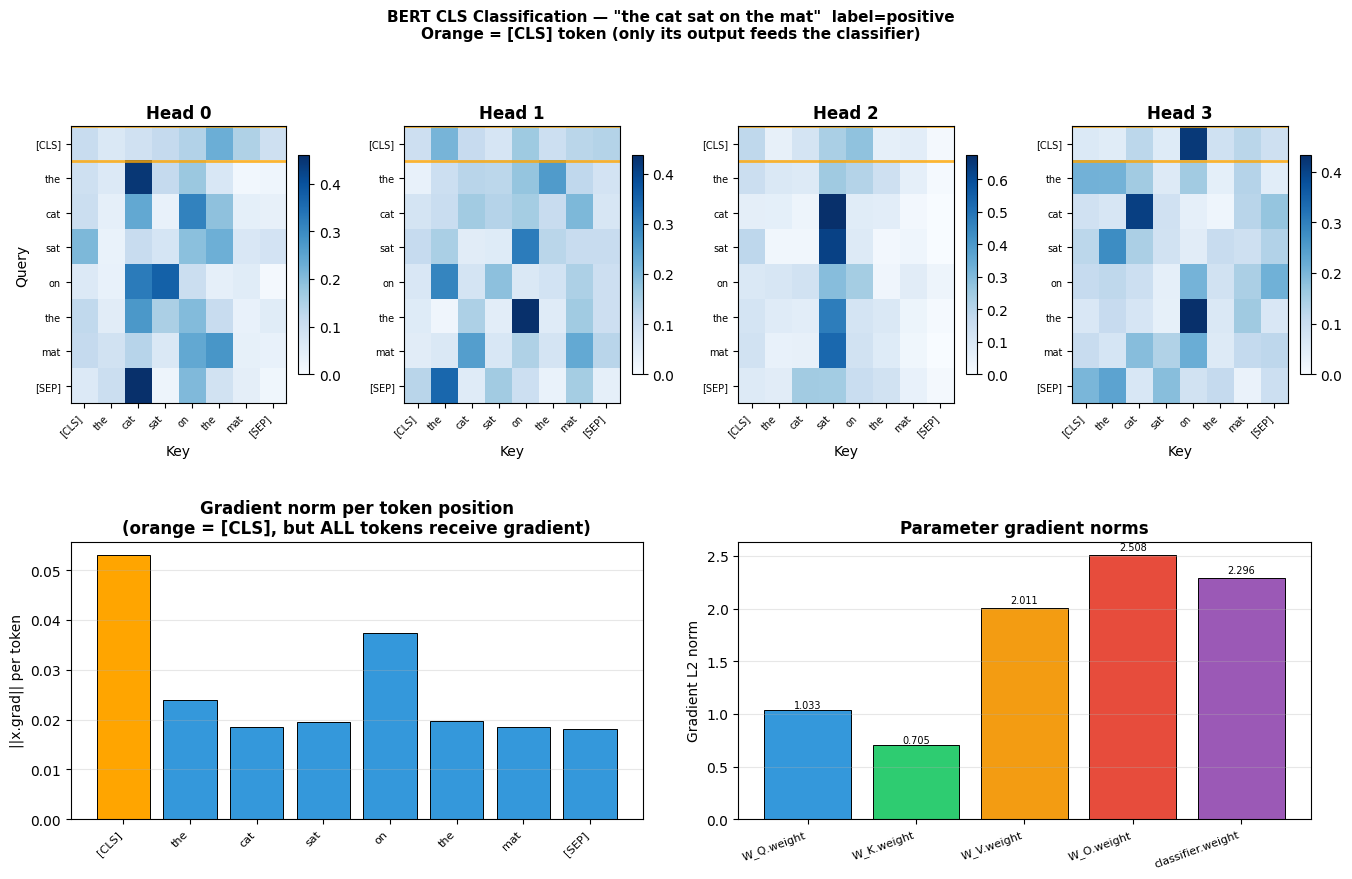


  Figure saved → 'bert_02_cls_classification.png'


In [13]:
# ── 9. Figures ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# (a) Attention heatmaps per head — highlight [CLS] row
for h in range(N_HEADS):
    ax = fig.add_subplot(gs[0, h])
    w  = attn_w[h].detach().numpy()
    im = ax.imshow(w, vmin=0, vmax=w.max(), cmap="Blues", aspect="auto")
    ax.set_title(f"Head {h}", fontweight="bold")
    ax.set_xticks(range(T)); ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(T)); ax.set_yticklabels(tokens, fontsize=7)
    if h == 0:
        ax.set_ylabel("Query")
    ax.set_xlabel("Key")
    # highlight [CLS] row — this is what feeds the classifier
    ax.axhline(0.5,  color="orange", lw=2, alpha=0.8)
    ax.axhline(-0.5, color="orange", lw=2, alpha=0.8)
    plt.colorbar(im, ax=ax, fraction=0.046)

# (b) x.grad norm per token
ax_grad = fig.add_subplot(gs[1, :2])
row_norms = x.grad.norm(dim=-1).detach().numpy()
colors    = ["orange"] + ["#3498db"] * (T - 1)
ax_grad.bar(range(T), row_norms, color=colors, edgecolor="black", lw=0.7)
ax_grad.set_xticks(range(T))
ax_grad.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
ax_grad.set_ylabel("||x.grad|| per token")
ax_grad.set_title("Gradient norm per token position\n"
                  "(orange = [CLS], but ALL tokens receive gradient)", fontweight="bold")
ax_grad.grid(axis="y", alpha=0.3)

# (c) Parameter gradient norms
ax_bar = fig.add_subplot(gs[1, 2:])
names  = list(params.keys())
norms  = [params[n].grad.norm().item() for n in names]
colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"]
bars   = ax_bar.bar(names, norms, color=colors, edgecolor="black", lw=0.7)
ax_bar.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
ax_bar.set_ylabel("Gradient L2 norm")
ax_bar.set_title("Parameter gradient norms", fontweight="bold")
ax_bar.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, norms):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val*1.02,
                f"{val:.3f}", ha="center", fontsize=7)

fig.suptitle(
    f'BERT CLS Classification — "{SENTENCE}"  label=positive\n'
    f'Orange = [CLS] token (only its output feeds the classifier)',
    fontsize=11, fontweight="bold", y=1.01
)
plt.savefig("bert_02_cls_classification.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Figure saved → 'bert_02_cls_classification.png'")